## Imports

In [1]:
import os
import json
import numpy as np
import pandas as pd
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
from tqdm import tqdm

- This is critical: xBD labels are JSON polygons, not masks.

- We must convert JSON → segmentation mask.

## Loading CSV

In [2]:
train_df = pd.read_csv(
    "/kaggle/input/datasets/neeldaiict/xbd-image-pairs-data/train_pairs.csv"
)

val_df = pd.read_csv(
    "/kaggle/input/datasets/neeldaiict/xbd-image-pairs-data/val_pairs.csv"
)

test_df = pd.read_csv(
    "/kaggle/input/datasets/neeldaiict/xbd-image-pairs-data/test_pairs.csv"
)

print("Train samples:", len(train_df))
print("Validation samples:", len(val_df))
print("Test samples:", len(test_df))

Train samples: 4458
Validation samples: 955
Test samples: 956


## Damage Class Mapping

In [3]:
DAMAGE_CLASSES = {
    "no-damage": 1,
    "minor-damage": 2,
    "major-damage": 3,
    "destroyed": 4
}

NUM_CLASSES = 5

print(DAMAGE_CLASSES)

{'no-damage': 1, 'minor-damage': 2, 'major-damage': 3, 'destroyed': 4}


## JSON to Mask Converter function

In [4]:
def json_to_mask(json_path, image_size):

    w, h = image_size

    mask = Image.new("L", (w, h), 0)
    draw = ImageDraw.Draw(mask)

    with open(json_path, "r") as f:
        data = json.load(f)

    features = data.get("features", {}).get("xy", [])

    for feat in features:

        props = feat.get("properties", {})
        subtype = props.get("subtype")

        if subtype not in DAMAGE_CLASSES:
            continue

        class_id = DAMAGE_CLASSES[subtype]

        wkt = feat.get("wkt")

        if not wkt:
            continue

        if "POLYGON" not in wkt:
            continue

        coords = (
            wkt.replace("POLYGON ((", "")
               .replace("))", "")
        )

        points = []

        for p in coords.split(","):

            x, y = p.strip().split()

            points.append(
                (float(x), float(y))
            )

        draw.polygon(points, fill=class_id)

    return np.array(mask, dtype=np.uint8)

## Creating output Directories

In [5]:
os.makedirs("processed_masks/train", exist_ok=True)
os.makedirs("processed_masks/val", exist_ok=True)
os.makedirs("processed_masks/test", exist_ok=True)

## Generating Training Masks

In [6]:
train_records = []

for _, row in tqdm(
    train_df.iterrows(),
    total=len(train_df)
):

    post_img = Image.open(
        row["post_image"]
    )

    mask = json_to_mask(
        row["label_json"],
        post_img.size
    )

    mask = Image.fromarray(mask)

    mask = mask.resize(
        (256, 256),
        resample=Image.NEAREST
    )

    base_name = (
        os.path.basename(row["post_image"])
        .replace(".png", "_mask.png")
    )

    mask_path = os.path.join(
        "processed_masks/train",
        base_name
    )

    mask.save(mask_path)

    train_records.append({
        "pre_image": row["pre_image"],
        "post_image": row["post_image"],
        "mask_path": mask_path
    })

# Verify all training samples were processed
assert len(train_records) == len(train_df)

print("Train masks generated:", len(train_records))

100%|██████████| 4458/4458 [02:06<00:00, 35.35it/s]

Train masks generated: 4458


## Generating Validation Masks

In [7]:
val_records = []

for _, row in tqdm(
    val_df.iterrows(),
    total=len(val_df)
):

    post_img = Image.open(
        row["post_image"]
    )

    mask = json_to_mask(
        row["label_json"],
        post_img.size
    )

    mask = Image.fromarray(mask)

    mask = mask.resize(
        (256, 256),
        resample=Image.NEAREST
    )

    base_name = (
        os.path.basename(row["post_image"])
        .replace(".png", "_mask.png")
    )

    mask_path = os.path.join(
        "processed_masks/val",
        base_name
    )

    mask.save(mask_path)

    val_records.append({
        "pre_image": row["pre_image"],
        "post_image": row["post_image"],
        "mask_path": mask_path
    })

assert len(val_records) == len(val_df)

print("Validation masks generated:", len(val_records))

100%|██████████| 955/955 [00:27<00:00, 34.16it/s]

Validation masks generated: 955


## Generate Test Masks

In [8]:
test_records = []

for _, row in tqdm(
    test_df.iterrows(),
    total=len(test_df)
):

    post_img = Image.open(
        row["post_image"]
    )

    mask = json_to_mask(
        row["label_json"],
        post_img.size
    )

    mask = Image.fromarray(mask)

    mask = mask.resize(
        (256, 256),
        resample=Image.NEAREST
    )

    base_name = (
        os.path.basename(row["post_image"])
        .replace(".png", "_mask.png")
    )

    mask_path = os.path.join(
        "processed_masks/test",
        base_name
    )

    mask.save(mask_path)

    test_records.append({
        "pre_image": row["pre_image"],
        "post_image": row["post_image"],
        "mask_path": mask_path
    })

assert len(test_records) == len(test_df)

print("Test masks generated:", len(test_records))

100%|██████████| 956/956 [00:26<00:00, 35.71it/s]

Test masks generated: 956


## Create Updated CSV Files

In [9]:
train_masks_df = pd.DataFrame(train_records)
val_masks_df = pd.DataFrame(val_records)
test_masks_df = pd.DataFrame(test_records)

train_masks_df.to_csv(
    "train_masks.csv",
    index=False
)

val_masks_df.to_csv(
    "val_masks.csv",
    index=False
)

test_masks_df.to_csv(
    "test_masks.csv",
    index=False
)

print("Saved:")
print("train_masks.csv")
print("val_masks.csv")
print("test_masks.csv")

Saved:
train_masks.csv
val_masks.csv
test_masks.csv


## Verify Saved Masks

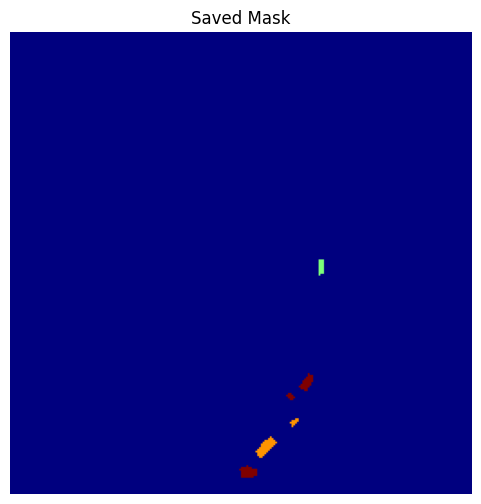

[0 2 3 4]


In [10]:
sample = train_masks_df.sample(1).iloc[0]

mask = Image.open(
    sample["mask_path"]
)

plt.figure(figsize=(6,6))

plt.imshow(mask, cmap="jet")

plt.title("Saved Mask")

plt.axis("off")

plt.show()

print(
    np.unique(
        np.array(mask)
    )
)

## Verify Dataset Statistics

In [11]:
print(
    "Train masks:",
    len(train_masks_df)
)

print(
    "Validation masks:",
    len(val_masks_df)
)

print(
    "Test masks:",
    len(test_masks_df)
)

print(
    "Mask classes:",
    NUM_CLASSES
)

Train masks: 4458
Validation masks: 955
Test masks: 956
Mask classes: 5


## Training Dataset Damage Class Distribution

In [13]:
from collections import Counter
import pandas as pd

counter = Counter()

for mask_path in train_masks_df["mask_path"]:

    mask = np.array(Image.open(mask_path))

    vals = np.unique(mask)

    for v in vals:
        counter[int(v)] += 1

class_names = {
    0: "Background",
    1: "No Damage",
    2: "Minor Damage",
    3: "Major Damage",
    4: "Destroyed"
}

stats_df = pd.DataFrame({
    "Class ID": list(counter.keys()),
    "Class Name": [class_names[c] for c in counter.keys()],
    "Images Containing Class": list(counter.values())
})

stats_df = stats_df.sort_values("Class ID")

print(stats_df.to_string(index=False))

 Class ID   Class Name  Images Containing Class
        0   Background                     4458
        1    No Damage                     2024
        2 Minor Damage                      651
        3 Major Damage                      604
        4    Destroyed                      790


,Class Name,Images Containing Class
0,Background,4458
1,No Damage,2024
2,Minor Damage,651
3,Major Damage,604
4,Destroyed,790


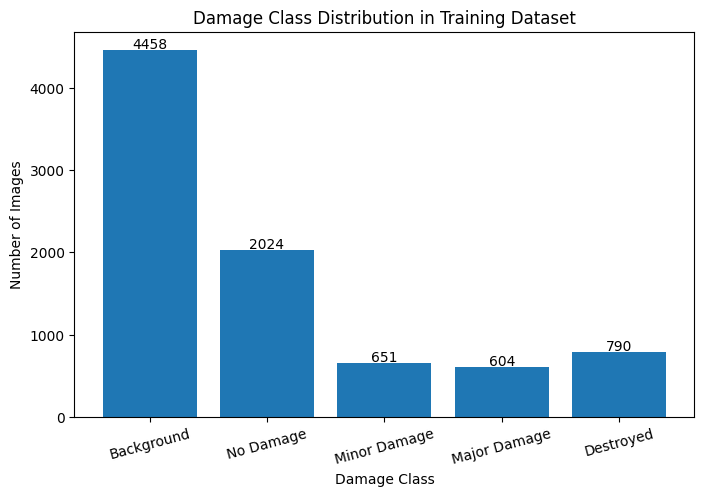

In [14]:
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

counter = Counter()

for mask_path in train_masks_df["mask_path"]:

    mask = np.array(Image.open(mask_path))

    vals = np.unique(mask)

    for v in vals:
        counter[int(v)] += 1

class_names = {
    0: "Background",
    1: "No Damage",
    2: "Minor Damage",
    3: "Major Damage",
    4: "Destroyed"
}

stats_df = pd.DataFrame({
    "Class Name": [class_names[c] for c in sorted(counter.keys())],
    "Images Containing Class": [counter[c] for c in sorted(counter.keys())]
})

display(stats_df)

plt.figure(figsize=(8, 5))
plt.bar(
    stats_df["Class Name"],
    stats_df["Images Containing Class"]
)

plt.title("Damage Class Distribution in Training Dataset")
plt.xlabel("Damage Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=15)

for i, value in enumerate(stats_df["Images Containing Class"]):
    plt.text(i, value + 20, str(value), ha="center")

plt.show()

## Validation Dataset Damage Class Distribution


Validation Dataset Size: 955 images



,Class ID,Class Name,Images Containing Class
0,0,Background,955
1,1,No Damage,415
2,2,Minor Damage,117
3,3,Major Damage,125
4,4,Destroyed,165


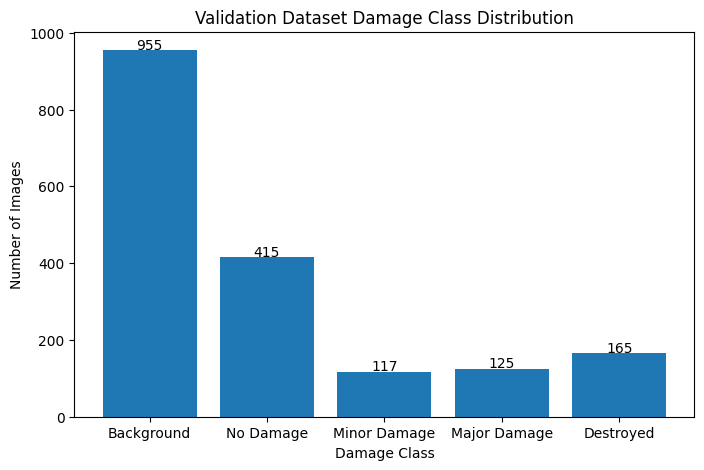

In [16]:
from collections import Counter

counter = Counter()

for mask_path in val_masks_df["mask_path"]:

    mask = np.array(Image.open(mask_path))

    unique_classes = np.unique(mask)

    for cls in unique_classes:
        counter[int(cls)] += 1

stats_df = pd.DataFrame({
    "Class ID": sorted(counter.keys()),
    "Class Name": [class_names[c] for c in sorted(counter.keys())],
    "Images Containing Class": [counter[c] for c in sorted(counter.keys())]
})

print(f"\nValidation Dataset Size: {len(val_masks_df)} images\n")
display(stats_df)

plt.figure(figsize=(8,5))

bars = plt.bar(
    stats_df["Class Name"],
    stats_df["Images Containing Class"]
)

plt.title("Validation Dataset Damage Class Distribution")
plt.xlabel("Damage Class")
plt.ylabel("Number of Images")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 3,
        str(int(height)),
        ha="center"
    )

plt.show()

## Test Dataset Damage Class Distribution


Test Dataset Size: 956 images



,Class ID,Class Name,Images Containing Class
0,0,Background,956
1,1,No Damage,452
2,2,Minor Damage,164
3,3,Major Damage,148
4,4,Destroyed,189


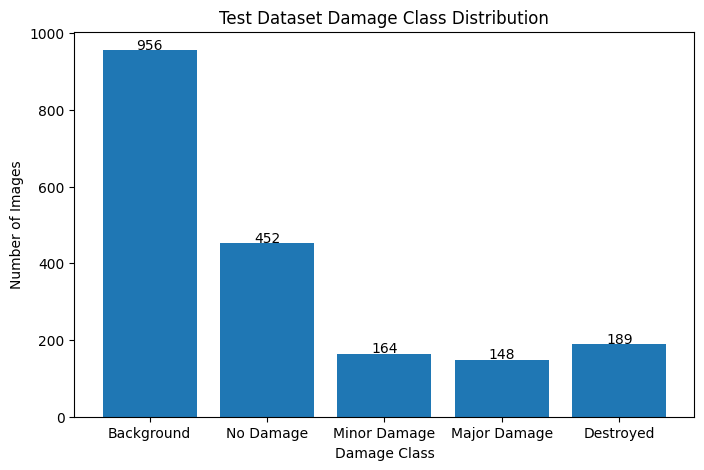

In [17]:
from collections import Counter

counter = Counter()

for mask_path in test_masks_df["mask_path"]:

    mask = np.array(Image.open(mask_path))

    unique_classes = np.unique(mask)

    for cls in unique_classes:
        counter[int(cls)] += 1

stats_df = pd.DataFrame({
    "Class ID": sorted(counter.keys()),
    "Class Name": [class_names[c] for c in sorted(counter.keys())],
    "Images Containing Class": [counter[c] for c in sorted(counter.keys())]
})

print(f"\nTest Dataset Size: {len(test_masks_df)} images\n")
display(stats_df)

plt.figure(figsize=(8,5))

bars = plt.bar(
    stats_df["Class Name"],
    stats_df["Images Containing Class"]
)

plt.title("Test Dataset Damage Class Distribution")
plt.xlabel("Damage Class")
plt.ylabel("Number of Images")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 3,
        str(int(height)),
        ha="center"
    )

plt.show()

## Entire Dataset Damage Class Distribution


Dataset Size: 6369 images



,Class ID,Class Name,Images Containing Class
0,0,Background,6369
1,1,No Damage,2891
2,2,Minor Damage,932
3,3,Major Damage,877
4,4,Destroyed,1144


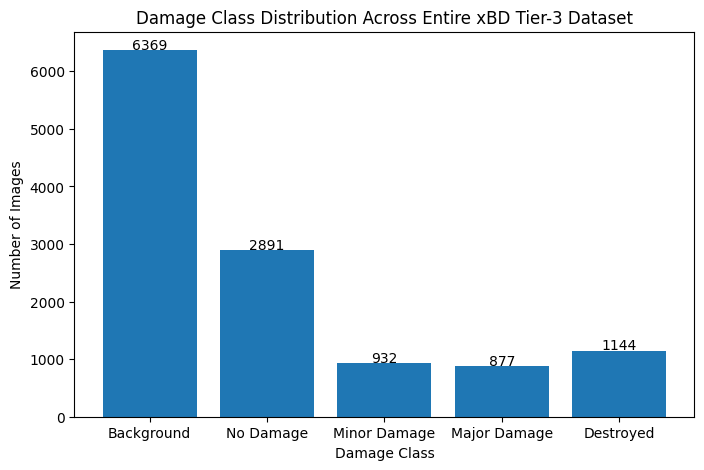

In [15]:
from collections import Counter
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# Combine all splits
all_masks_df = pd.concat(
    [train_masks_df, val_masks_df, test_masks_df],
    ignore_index=True
)

counter = Counter()

for mask_path in all_masks_df["mask_path"]:

    mask = np.array(Image.open(mask_path))

    unique_classes = np.unique(mask)

    for cls in unique_classes:
        counter[int(cls)] += 1

class_names = {
    0: "Background",
    1: "No Damage",
    2: "Minor Damage",
    3: "Major Damage",
    4: "Destroyed"
}

stats_df = pd.DataFrame({
    "Class ID": sorted(counter.keys()),
    "Class Name": [class_names[c] for c in sorted(counter.keys())],
    "Images Containing Class": [counter[c] for c in sorted(counter.keys())]
})

print("\nDataset Size:", len(all_masks_df), "images\n")
display(stats_df)

# Visualization
plt.figure(figsize=(8,5))

bars = plt.bar(
    stats_df["Class Name"],
    stats_df["Images Containing Class"]
)

plt.title(
    "Damage Class Distribution Across Entire xBD Tier-3 Dataset"
)

plt.xlabel("Damage Class")
plt.ylabel("Number of Images")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 20,
        f"{int(height)}",
        ha="center"
    )

plt.show()

## Pixel-Level Damage Class Distribution (Entire Dataset)

In [18]:
from collections import Counter
import pandas as pd
import numpy as np
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt

pixel_counter = Counter()

# Combine all masks
all_masks_df = pd.concat(
    [train_masks_df, val_masks_df, test_masks_df],
    ignore_index=True
)

for mask_path in tqdm(
    all_masks_df["mask_path"],
    total=len(all_masks_df)
):

    mask = np.array(Image.open(mask_path))

    unique, counts = np.unique(
        mask,
        return_counts=True
    )

    for cls, count in zip(unique, counts):
        pixel_counter[int(cls)] += int(count)

class_names = {
    0: "Background",
    1: "No Damage",
    2: "Minor Damage",
    3: "Major Damage",
    4: "Destroyed"
}

total_pixels = sum(pixel_counter.values())

stats_df = pd.DataFrame({
    "Class ID": sorted(pixel_counter.keys()),
    "Class Name": [class_names[c] for c in sorted(pixel_counter.keys())],
    "Pixel Count": [pixel_counter[c] for c in sorted(pixel_counter.keys())]
})

stats_df["Percentage"] = (
    stats_df["Pixel Count"] / total_pixels * 100
).round(4)

display(stats_df)

print(f"\nTotal Pixels: {total_pixels:,}")

100%|██████████| 6369/6369 [00:07<00:00, 898.20it/s]


,Class ID,Class Name,Pixel Count,Percentage
0,0,Background,410469786,98.3400
1,1,No Damage,5564167,1.3331
2,2,Minor Damage,540478,0.1295
3,3,Major Damage,347612,0.0833
4,4,Destroyed,476741,0.1142



Total Pixels: 417,398,784


### Percentage Visualization

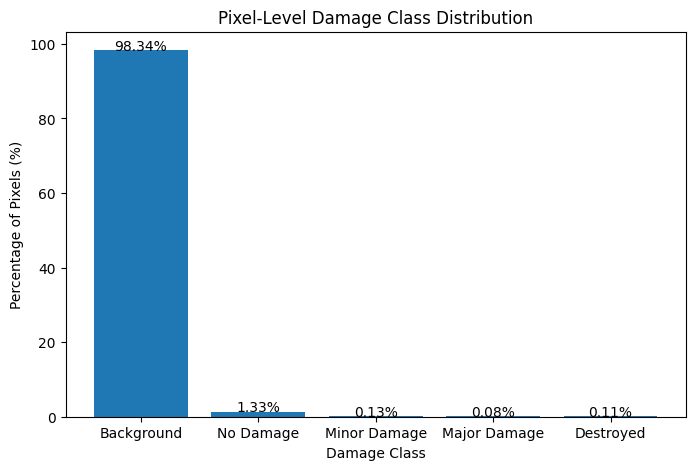

In [19]:
plt.figure(figsize=(8,5))

bars = plt.bar(
    stats_df["Class Name"],
    stats_df["Percentage"]
)

plt.title(
    "Pixel-Level Damage Class Distribution"
)

plt.xlabel("Damage Class")
plt.ylabel("Percentage of Pixels (%)")

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.2f}%",
        ha="center"
    )

plt.show()

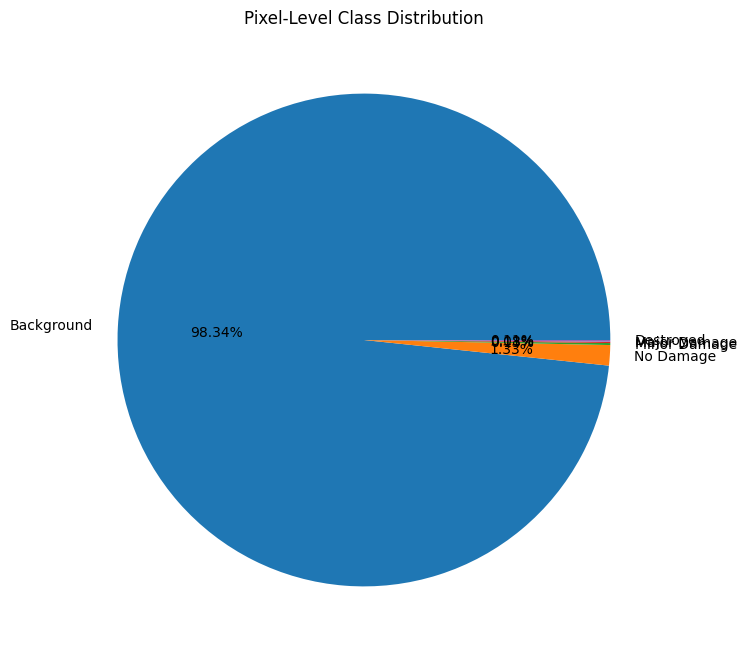

In [20]:
plt.figure(figsize=(8,8))

plt.pie(
    stats_df["Pixel Count"],
    labels=stats_df["Class Name"],
    autopct="%1.2f%%"
)

plt.title(
    "Pixel-Level Class Distribution"
)

plt.show()

### Storing the pixel stats in csv

In [21]:
stats_df.to_csv(
    "pixel_class_distribution.csv",
    index=False
)

print("Saved pixel_class_distribution.csv")

Saved pixel_class_distribution.csv


## Class Imbalance Analysis

- Pixel-level analysis shows that 98.34% of pixels belong to the background class, while all damage classes together constitute less than 0.35% of the dataset.
- This severe class imbalance motivates the use of weighted loss functions and Dice-based optimization during model training.